RESULTADOS DO EXERCÍCIO 1
Melhor custo COM elitismo: 198.84
Melhor custo SEM elitismo: 181.98


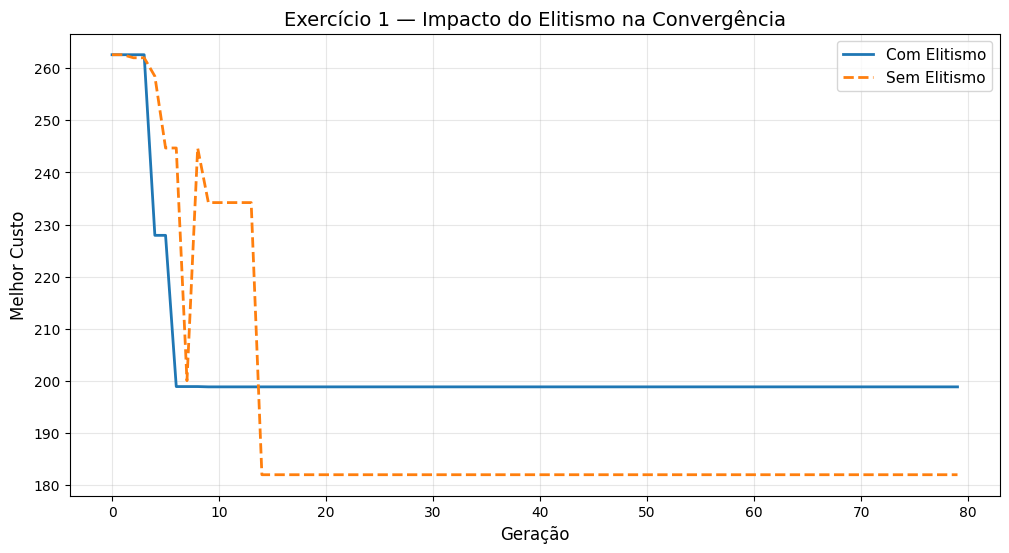

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. FUNÇÃO DE CÁLCULO DO CUSTO
# ============================================================

def calcular_custo(rota, matriz):
    """
    Calcula o custo total de uma rota fechada.

    Exemplo:
    [0, 2, 1, 3]

    representa:
    0 → 2 → 1 → 3 → 0
    """

    dist = 0

    for i in range(len(rota) - 1):
        dist += matriz[rota[i], rota[i + 1]]

    # Retorna ao primeiro nó
    dist += matriz[rota[-1], rota[0]]

    return dist


# ============================================================
# 2. CONFIGURAÇÕES DO PROBLEMA
# ============================================================

NUM_NOS = 8
TAM_POP = 40
GERACOES = 80

# Taxa de mutação
TAXA_MUTACAO = 0.30

# Semente para tornar o experimento reproduzível
np.random.seed(42)


# ============================================================
# 3. CRIAÇÃO DA MATRIZ DE DISTÂNCIAS
# ============================================================

matriz_teste = np.random.uniform(
    10,
    100,
    (NUM_NOS, NUM_NOS)
)


# ============================================================
# 4. FUNÇÃO DO ALGORITMO GENÉTICO
# ============================================================

def executar_algoritmo(usar_elitismo, semente=42):

    # --------------------------------------------------------
    # Controla a aleatoriedade
    # --------------------------------------------------------

    np.random.seed(semente)


    # --------------------------------------------------------
    # Criação da população inicial
    # --------------------------------------------------------

    populacao = [
        np.random.permutation(NUM_NOS)
        for _ in range(TAM_POP)
    ]


    # --------------------------------------------------------
    # Histórico do melhor custo
    # --------------------------------------------------------

    historico_melhor = []


    # ========================================================
    # 5. LOOP DAS GERAÇÕES
    # ========================================================

    for g in range(GERACOES):


        # ----------------------------------------------------
        # Calcula o custo de todos os indivíduos
        # ----------------------------------------------------

        custos = [
            calcular_custo(
                individuo,
                matriz_teste
            )
            for individuo in populacao
        ]


        # ----------------------------------------------------
        # Encontra o melhor indivíduo da geração
        # ----------------------------------------------------

        melhor_idx = np.argmin(custos)

        melhor_custo = custos[melhor_idx]


        # ----------------------------------------------------
        # Guarda o melhor custo da geração
        # ----------------------------------------------------

        historico_melhor.append(
            melhor_custo
        )


        # ----------------------------------------------------
        # Cria a nova população
        # ----------------------------------------------------

        novos = []


        # ====================================================
        # ELITISMO
        # ====================================================

        if usar_elitismo:

            # Copia o melhor indivíduo para a
            # próxima geração

            novos.append(
                populacao[melhor_idx].copy()
            )


        # ====================================================
        # REPRODUÇÃO
        # ====================================================

        while len(novos) < TAM_POP:


            # ------------------------------------------------
            # Escolhe dois indivíduos aleatoriamente
            # ------------------------------------------------

            i1, i2 = np.random.choice(
                TAM_POP,
                2,
                replace=False
            )


            # ------------------------------------------------
            # Seleção por torneio
            # ------------------------------------------------

            if custos[i1] < custos[i2]:

                pai = populacao[i1]

            else:

                pai = populacao[i2]


            # ------------------------------------------------
            # Cria o filho copiando o pai
            # ------------------------------------------------

            filho = pai.copy()


            # =================================================
            # MUTAÇÃO
            # =================================================

            if np.random.rand() < TAXA_MUTACAO:


                # Escolhe duas posições da rota

                idx1, idx2 = np.random.choice(
                    NUM_NOS,
                    2,
                    replace=False
                )


                # Troca os dois nós

                filho[idx1], filho[idx2] = (
                    filho[idx2],
                    filho[idx1]
                )


            # ------------------------------------------------
            # Adiciona o filho à nova população
            # ------------------------------------------------

            novos.append(filho)


        # ----------------------------------------------------
        # Substitui a população antiga
        # ----------------------------------------------------

        populacao = novos


    # ========================================================
    # 6. AVALIAÇÃO FINAL
    # ========================================================

    custos_finais = [
        calcular_custo(
            individuo,
            matriz_teste
        )
        for individuo in populacao
    ]


    melhor_custo_final = min(custos_finais)


    return (
        melhor_custo_final,
        historico_melhor
    )


# ============================================================
# 7. EXECUÇÃO COM ELITISMO
# ============================================================

resultado_com_elitismo, historico_com_elitismo = (
    executar_algoritmo(
        usar_elitismo=True,
        semente=42
    )
)


# ============================================================
# 8. EXECUÇÃO SEM ELITISMO
# ============================================================

resultado_sem_elitismo, historico_sem_elitismo = (
    executar_algoritmo(
        usar_elitismo=False,
        semente=42
    )
)


# ============================================================
# 9. RESULTADOS
# ============================================================

print("=" * 60)
print("RESULTADOS DO EXERCÍCIO 1")
print("=" * 60)

print(
    f"Melhor custo COM elitismo: "
    f"{resultado_com_elitismo:.2f}"
)

print(
    f"Melhor custo SEM elitismo: "
    f"{resultado_sem_elitismo:.2f}"
)

print("=" * 60)


# ============================================================
# 10. GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(12, 6))


plt.plot(
    historico_com_elitismo,
    label="Com Elitismo",
    linewidth=2
)


plt.plot(
    historico_sem_elitismo,
    label="Sem Elitismo",
    linewidth=2,
    linestyle="--"
)


plt.title(
    "Exercício 1 — Impacto do Elitismo na Convergência",
    fontsize=14
)

plt.xlabel(
    "Geração",
    fontsize=12
)

plt.ylabel(
    "Melhor Custo",
    fontsize=12
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend(
    fontsize=11
)


plt.show()